In [55]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np


In [56]:
data = pd.read_csv(r"Z:\Intermship\task#01\hotel_dataset.csv")
data.head()
data_before=data


In [57]:
print(data.isnull().sum())


booking_id            0
guest_name         1342
email               329
listing_id            0
listing_city          0
checkin_date          0
checkout_date         1
nights               97
price_per_night     146
payment_status     1988
review_score       2662
is_cancelled          1
dtype: int64


In [58]:
data['listing_city'].unique()
type1=['nyc', 'San Francisco', 'San Fran', 'New York', 'Los Angeles',
       'los angeles', 'new york', 'LA', 'NYC', 'SF']
dict={i:val for val,i in enumerate(type1)}
print(dict)


{'nyc': 0, 'San Francisco': 1, 'San Fran': 2, 'New York': 3, 'Los Angeles': 4, 'los angeles': 5, 'new york': 6, 'LA': 7, 'NYC': 8, 'SF': 9}


In [59]:
data['listing_city']=data['listing_city'].map(dict)

In [60]:
data['payment_status'].unique()
type2=['paid', 'PENDING', 'pending', 'Paid', 'Unpaid']
dict={i:val for val,i in enumerate(type2)}
print(dict)
data['payment_status']=data['payment_status'].map(dict)


{'paid': 0, 'PENDING': 1, 'pending': 2, 'Paid': 3, 'Unpaid': 4}


In [73]:
data['is_cancelled'].unique()
type3=['0', 'No', 'Yes', 'n', '1', 'FALSE', 'TRUE', 'y']
dict={i:val for val,i in enumerate(type3)}
print(dict)
data['payment_status']=data['payment_status'].map(dict)

{'0': 0, 'No': 1, 'Yes': 2, 'n': 3, '1': 4, 'FALSE': 5, 'TRUE': 6, 'y': 7}


In [61]:
#print(data['price_per_night'].dtypes)
data.head()


,booking_id,guest_name,email,listing_id,listing_city,checkin_date,checkout_date,nights,price_per_night,payment_status,review_score,is_cancelled
0,BKG-013035,NaN,nhoffman@scott.com,1083,4,5/24/2023,12/12/2023,-1,245.61,NaN,6.0,FALSE
1,BKG-003115,CAROLYN SHAH,achan@olson-nelson.com,1079,5,8/19/2024,11/8/2024,81,51.96,NaN,6.0,Yes
2,BKG-008732,Jermaine Huang,thomasadam@yahoo.com,1036,2,3/20/2024,3/3/2025,348,383.63,3.0,1.0,FALSE
3,BKG-007591,amy rios,reginald31@robertson-smith.com,1025,7,2/29/2024,3/16/2025,381,268.36,NaN,6.0,n
4,BKG-000221,NaN,NaN,1089,7,1/26/2025,2/22/2025,27,134.71,NaN,NaN,TRUE


In [62]:
cag=data[['listing_city','email','guest_name','payment_status','is_cancelled','nights']]
for i in cag:
    data[i]=data[i].fillna(data[i].mode()[0])
data.head()    


,booking_id,guest_name,email,listing_id,listing_city,checkin_date,checkout_date,nights,price_per_night,payment_status,review_score,is_cancelled
0,BKG-013035,Jonathan Richard,nhoffman@scott.com,1083,4,5/24/2023,12/12/2023,-1,245.61,3.0,6.0,FALSE
1,BKG-003115,CAROLYN SHAH,achan@olson-nelson.com,1079,5,8/19/2024,11/8/2024,81,51.96,3.0,6.0,Yes
2,BKG-008732,Jermaine Huang,thomasadam@yahoo.com,1036,2,3/20/2024,3/3/2025,348,383.63,3.0,1.0,FALSE
3,BKG-007591,amy rios,reginald31@robertson-smith.com,1025,7,2/29/2024,3/16/2025,381,268.36,3.0,6.0,n
4,BKG-000221,Jonathan Richard,adamsdavid@hotmail.com,1089,7,1/26/2025,2/22/2025,27,134.71,3.0,NaN,TRUE


In [63]:
data['price_per_night']=data['price_per_night'].fillna(data['price_per_night'].mode())
data['review_score']=data['review_score'].fillna(data['review_score'].mode())
data.head()    

,booking_id,guest_name,email,listing_id,listing_city,checkin_date,checkout_date,nights,price_per_night,payment_status,review_score,is_cancelled
0,BKG-013035,Jonathan Richard,nhoffman@scott.com,1083,4,5/24/2023,12/12/2023,-1,245.61,3.0,6.0,FALSE
1,BKG-003115,CAROLYN SHAH,achan@olson-nelson.com,1079,5,8/19/2024,11/8/2024,81,51.96,3.0,6.0,Yes
2,BKG-008732,Jermaine Huang,thomasadam@yahoo.com,1036,2,3/20/2024,3/3/2025,348,383.63,3.0,1.0,FALSE
3,BKG-007591,amy rios,reginald31@robertson-smith.com,1025,7,2/29/2024,3/16/2025,381,268.36,3.0,6.0,n
4,BKG-000221,Jonathan Richard,adamsdavid@hotmail.com,1089,7,1/26/2025,2/22/2025,27,134.71,3.0,NaN,TRUE


In [64]:
print(data['price_per_night'].dtypes)

object


In [65]:
data['price_per_night'] = pd.to_numeric(data['price_per_night'],errors='coerce')
data['price_per_night'] = data['price_per_night'].fillna(data['price_per_night'].median())
data['review_score'] = pd.to_numeric(data['review_score'])
data['review_score'] = data['review_score'].fillna(data['review_score'].median())
data['guest_name'] = data['guest_name'].str.strip().str.title()
data = data[data['email'].str.contains("@", na=False)]

In [66]:
print(data['checkout_date'].dtypes)
data['checkout_date'] = pd.to_datetime(data['checkout_date'], errors='coerce')
data['checkout_date'] = data['checkout_date'].fillna(data['checkout_date'].median())


object


In [67]:
print(data.isnull().sum())

booking_id         0
guest_name         0
email              0
listing_id         0
listing_city       0
checkin_date       0
checkout_date      0
nights             0
price_per_night    0
payment_status     0
review_score       0
is_cancelled       0
dtype: int64


In [68]:
g = data.groupby('review_score') 

min_size = g.size().min()
data = g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)
 
data.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_13760\2041127835.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)


,booking_id,guest_name,email,listing_id,listing_city,checkin_date,checkout_date,nights,price_per_night,payment_status,review_score,is_cancelled
0,BKG-003686,Kyle Davis,brittany11@hotmail.com,1043,7,8/12/2023,2023-09-02,21,318.34,4.0,-1.0,0
1,BKG-016404,Glen Velazquez,rnoble@gmail.com,1076,0,7/14/2023,2025-03-27,622,495.01,4.0,-1.0,No
2,BKG-017877,James Villarreal,angelicaking@yahoo.com,1001,8,3/16/2025,2025-04-23,38,384.55,4.0,-1.0,Yes
3,BKG-011184,Christopher Ochoa,owilliams@thomas.org,1000,1,31/08/2024,2025-01-14,136,391.85,3.0,-1.0,n
4,BKG-002642,Jerry Vargas,ericksonkatherine@jenkins-thomas.com,1012,8,12/30/2023,2024-03-19,80,446.99,3.0,-1.0,Yes


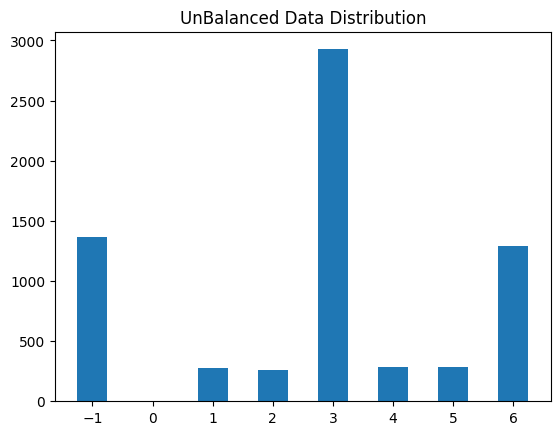

In [69]:
data_plot=data_before['review_score'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("UnBalanced Data Distribution")
plt.show()

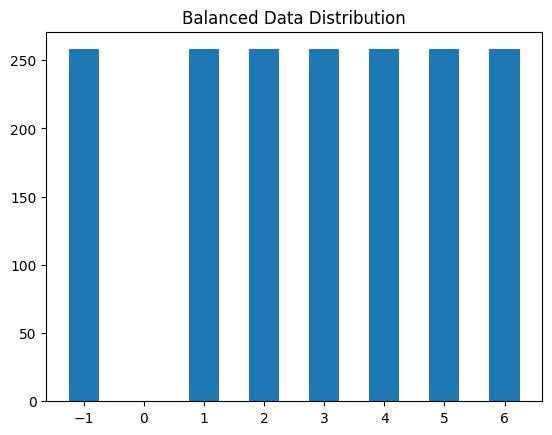

In [70]:
data_plot=data['review_score'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("Balanced Data Distribution")
plt.show()
